In [5]:
import os
import phaseco as pc
import numpy as np
import pandas as pd
# %matplotlib ipympl
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.signal import correlate, get_window, convolve, correlation_lags, hilbert

%load_ext autoreload
%autoreload

dirs = {}
dirs["oto"] = r"c:\\Users\\setht\\Dropbox\\Citadel\\GitHub\\otocoherence"

# Get subfolders
for subfolder in ["scripts", "results", "pickles"]:
    dirs[subfolder] = os.path.join(dirs["oto"], subfolder)
    
# subsubdirs
for results_subfolder in ["psd", "acf"]:
    dirs[results_subfolder] = os.path.join(dirs["results"], results_subfolder)


for dir in dirs.values():
    os.makedirs(dir, exist_ok=True)

os.chdir(dirs["scripts"])
%autoreload
from helper_funcs import *
os.chdir(dirs["oto"])



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
def exp_decay(x, a, T_xi):
    return a*np.exp(-x/T_xi)

def fit_exp(x, acf):
    # --- Initial guesses ---
    a_guess = 1
    T_xi_guess = 0.01

    # --- Bounds ---
    a_bounds = (0, np.inf)
    T_xi_bounds = (0, np.inf)


    bounds = (
        [a_bounds[0], T_xi_bounds[0]],
        [a_bounds[1], T_xi_bounds[1]]
    )

    p0 = [a_guess, T_xi_guess]

    # --- Fit ---
    try:
        popt, pcov = curve_fit(exp_decay, x, acf, p0=p0, bounds=bounds)
    except RuntimeError:
        print("Exponential fit did not converge, returning initial guess.")
        popt = p0
    a, T_xi = popt
    exp_fit = exp_decay(x, a, T_xi)

    return a, T_xi, exp_fit


Filtering wf with cf=(np.float64(1161.775134068159), np.float64(1304.4717278858059))Hz, df=71.34829690882336Hz, rip=50dB
Filtering took 0.565s
[ 134000  135000  136000 ... 1310000 1311000 1312000]
Filtering wf with cf=(np.float64(2055.8923221190043), np.float64(2254.8913704068364))Hz, df=99.4995241439162Hz, rip=50dB
Filtering took 0.500s
[ 97000  98000  99000 100000 101000 102000 103000 104000 105000 106000
 107000 108000 109000 110000 111000 112000 113000 114000 115000 116000
 117000 118000 119000 120000 121000 122000 123000 124000 125000 126000
 127000 128000 129000 130000 131000 132000 133000 134000 135000 136000
 137000 138000 139000 140000 141000 142000 143000 144000 145000 146000
 147000 148000 149000 150000 151000 152000 153000 154000 155000 156000
 157000 158000 159000 160000 161000 162000 163000 164000 165000 166000
 167000 168000 169000 170000 171000 172000 173000 174000 175000 176000
 177000 178000 179000 180000 181000 182000 183000 184000 185000 186000
 187000 188000 189000

KeyboardInterrupt: 

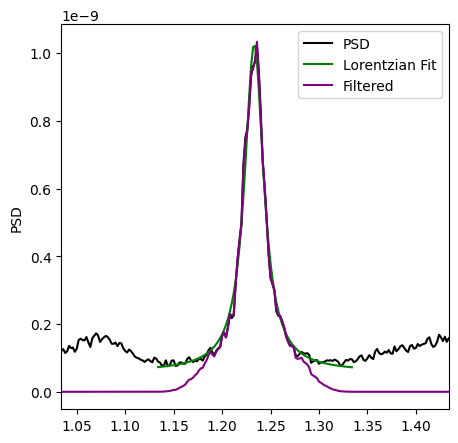

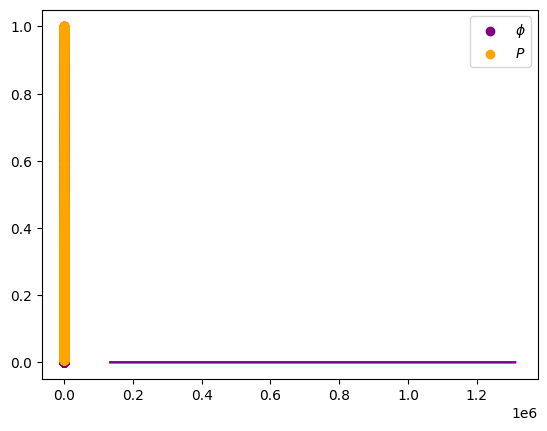

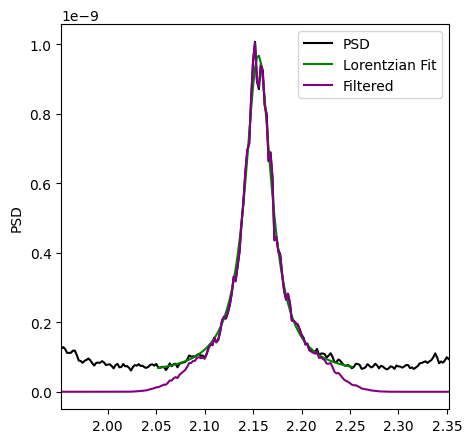

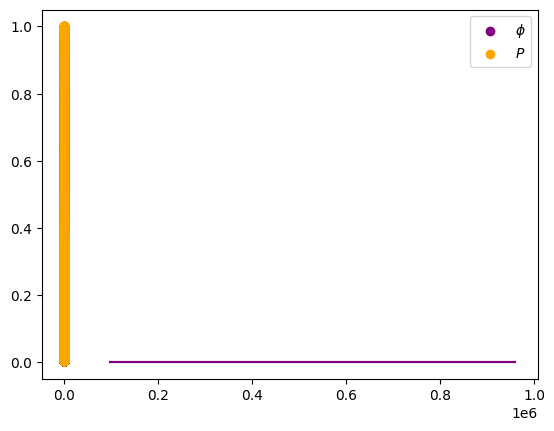

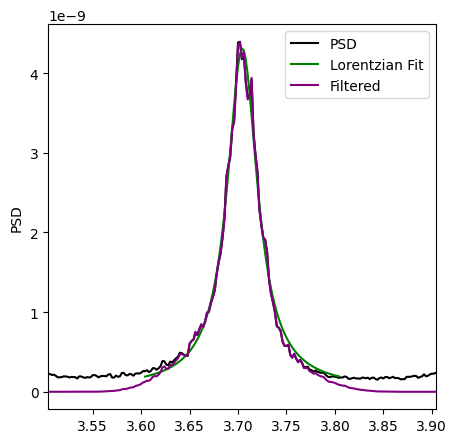

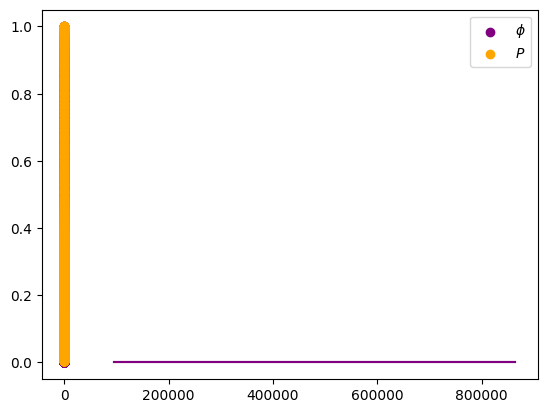

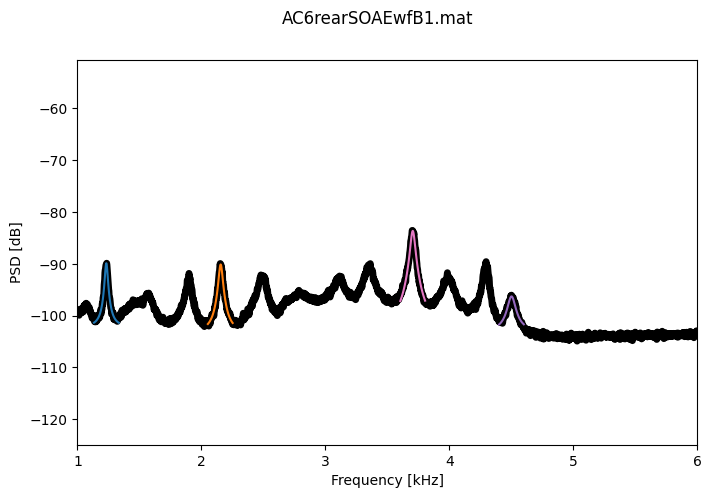

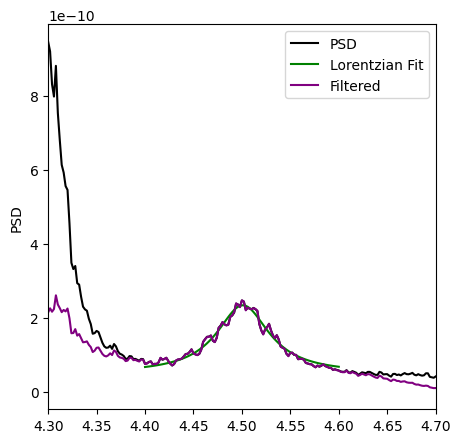

In [ ]:
plt.close('all')
speciess = ['Anole', 'Tokay', 'Human', 'Owl']
speciess = ['Anole']
wf_idxs = [0]
wf_len_s = 60

# Parameters

# ---PSD---
tau_s_psd = 0.5
win_type_psd = 'hann'
hop_s_psd = 0.25

# ---Plots---
flims = {'Anole':[1, 6], 'Human':[1, 10], 'Owl':[1, 12], 'Tokay':[1, 6]}
bw_crop = 200
figsize_psd = (8, 5)
figsize_ind = (5, 5)
ind_extra_bins = 50

# ---Filtering---
bw_mult = 6
df_mult = 3
rip = 50

# ---ACF---
max_lag_s = 0.1
acf_fit_min = 0.1
acf_fit_max = 0.9

# ---Filtering---
def filter_wf(wf, gamma, f0, bw_mult, df_mult, rip):
    fwhm = gamma * 2
    bw = fwhm*bw_mult
    cf = (f0-bw/2, f0+bw/2)
    df = fwhm*df_mult
    wf_filt = kaiser_filter(wf, fs, cf, df, rip)
    return wf_filt

# Initialize spreadsheet rows
rows = []

# ID
fn_id = f"bw={bw_mult}fwhm, df={df_mult}fwhm, rip={rip}db, bw_crop={bw_crop}Hz"

for species in speciess:
    for wf_idx in wf_idxs:
        # Get wf
        wf, wf_fn, fs, gpf, bpf = get_wf(species=species, wf_idx=wf_idx)
        wf = crop_wf(wf, fs, wf_len_s)
        
        # Convert from fs
        tau_psd = int(round(tau_s_psd * fs))
        hop_psd = int(round(hop_s_psd * fs))

        # Get species specific
        flim = flims[species]

        # Get psd for plotting
        f, psd = pc.get_welch(wf, fs, tau_psd, hop=hop_psd, win=win_type_psd)
        psd_db = 10*np.log10(psd)
        f_khz = f / 1000

        # Plot PSD
        plt.figure("full", figsize=figsize_psd)
        plt.plot(f_khz, psd_db, label='PSD', color='k', lw=5)
        plt.xlim(flims[species])
        plt.ylabel("PSD [dB]")
        plt.xlabel("Frequency [kHz]")
        plt.suptitle(wf_fn)

        # Get Lorentzian fits
        for f0, color in zip(gpf, get_colors('good')):
            # Crop axes
            f0_exact = f[np.argmin(np.abs(f-f0))]
            crop_idxs = [np.argmin(np.abs(f-(f0_exact-bw_crop/2))), np.argmin(np.abs(f-(f0_exact+bw_crop/2)))+1]
            f_crop = f[crop_idxs[0]:crop_idxs[1]]
            psd_crop = psd[crop_idxs[0]:crop_idxs[1]]
            # Fit Lorentzian
            f0_fit, y0_l, gamma_l, A_l, lorentz_fit = fit_lorentzian(f_crop, psd_crop)
            # Conversions
            f_crop_khz = f_crop / 1000
            psd_crop_db = psd_db[crop_idxs[0]:crop_idxs[1]]
            lorentz_fit_db = 10*np.log10(lorentz_fit)

            # Plot crop and fit on full PSD
            # plt.plot(f_crop_khz, psd_crop_db, color='yellow')
            plt.figure("full")
            plt.plot(f_crop_khz, lorentz_fit_db, label=f"{f0} Hz", color=color)
            
            # Crop to the fit plus some bins
            crop_plus_slice = slice(crop_idxs[0] - ind_extra_bins, crop_idxs[1] + ind_extra_bins)
            f_khz_crop_plus = f_khz[crop_plus_slice]
            psd_crop_plus = psd[crop_plus_slice]
            psd_crop_plus_db = psd_db[crop_plus_slice]
            
            # Filter and demean
            wf_filt = filter_wf(wf, gamma_l, f0_fit, bw_mult, df_mult, rip)
            wf_filt = wf_filt - np.mean(wf_filt)
            psd_filt = pc.get_welch(wf_filt, fs, tau_psd, hop=hop_psd, win=win_type_psd)[1]
            psd_filt_db = 10*np.log10(psd_filt)

            # Plot individual fits
            plt.figure(f"{f0}", figsize=figsize_ind)
            plt.plot(f_khz_crop_plus, psd_crop_plus, label='PSD', color='k')
            plt.plot(f_crop_khz, lorentz_fit, label="Lorentzian Fit", color='green')
            plt.plot(f_khz, psd_filt, label="Filtered", color='purple')
            plt.ylabel("PSD")
            plt.legend()
            plt.xlim(f_khz_crop_plus[[0, -1]])
            plt.savefig(os.path.join(dirs["psd"], f"{species} {wf_idx} {f0} Hz [{fn_id}] - PSD"))

            # Get N_xi
            wf_filt_h = hilbert(wf_filt)
            wf_filt_h_phi = wf_filt_h / np.abs(wf_filt_h)
            acf = correlate(wf_filt_h, wf_filt_h, mode='full', method='auto')
            acf_phi = correlate(wf_filt_h_phi, wf_filt_h_phi, mode='full', method='auto')
            
            # Get lags and crop both to positive lags
            N = len(wf_filt_h)
            lags = correlation_lags(N, N, mode='full')

            # Crop acf
            max_lag_idx = np.argmin(np.abs(lags-max_lag_s*fs))
            acf_slice = slice(N-1, max_lag_idx+1) # Final lag is max_lag_s (inclusive)
            lags = lags[acf_slice]
            acf = acf[acf_slice]
            acf_phi = acf_phi[acf_slice]

            # Normalize acf 
            num_terms = N-lags
            var = np.abs(acf[0])/N
            acf = np.abs(acf)/(num_terms*var)
            acf_phi = np.abs(acf_phi) / num_terms

            # Convert lags to ms
            lags_ms = lags * 1000 / fs

            # Crop to fit exponentials
            acf_crop_min_idx = np.argmin(np.abs(acf-acf_fit_max))
            acf_crop_max_idx = np.argmin(np.abs(acf-acf_fit_min))
            acf_crop_slice = slice(acf_crop_min_idx, acf_crop_max_idx)
            acf_crop = acf[acf_crop_slice]
            acf_phi_crop = acf_phi[acf_crop_slice]
            lags_crop = lags[acf_crop_slice]
            lags_crop_s =
            lags_crop_ms = lags_crop*1000 / fs
            print(lags_crop_ms)
            
            # Fit exponentials
            A_xi, T_xi, acf_fit = fit_exp(lags_crop, acf_crop)
            A_xi_phi, T_xi_phi, acf_phi_fit = fit_exp(lags_crop, acf_phi_crop)

            # Plot ACF
            plt.figure(f"{f0} ACF")
            plt.scatter(lags_ms, acf_phi, label=r"$\phi$", color='purple')
            plt.scatter(lags_ms, acf, label=r"$P$", color='orange')
            plt.plot(lags_crop_ms, acf_fit, color='purple')
            plt.plot(lags_crop_ms, acf_phi_fit, color='purple')
            plt.legend()
            plt.savefig(os.path.join(dirs["acf"], f"{species} {wf_idx} {f0} Hz [{fn_id}] - ACF"))
            row = {'species':species, 'wf_idx':wf_idx, 'f0_fit':f0_fit, 'mode':'P', 'T_xi':T_xi, 'A_xi':A_xi, 'gamma_l':gamma_l, 'A_l':A_l, 'fn':wf_fn, 'f0_exact':f0_exact, 'f0_guess':f0}
            row_phi = {'species':species, 'wf_idx':wf_idx, 'f0_fit':f0_fit, 'mode':'phi', 'T_xi':T_xi_phi, 'A_xi':A_xi_phi, 'gamma_l':gamma_l, 'A_l':A_l, 'wf_fn':wf_fn, 'f0_exact':f0_exact, 'f0_guess':f0}
            rows.append(row)
            rows.append(row_phi)

        # Save final full figure
        plt.figure("full")
        plt.legend()
        plt.title(fn_id)
        plt.savefig(os.path.join(dirs["psd"], f"{species} {wf_idx} Full PSD [{fn_id}]"))
        
        plt.show()


        
        



        

Designing Kaiser filter with 270 taps and beta=21.08


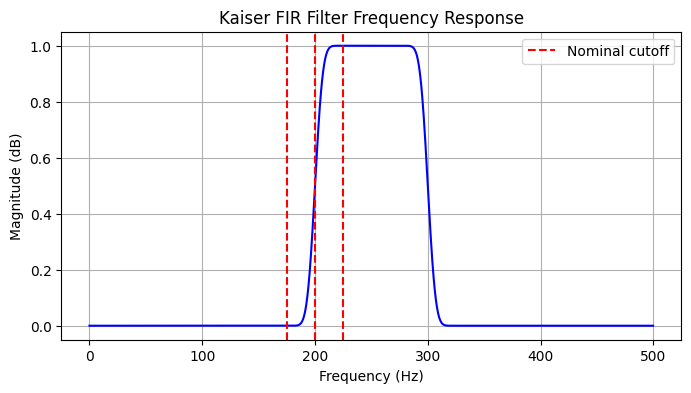

Designing Kaiser filter with 1730 taps and beta=109.24


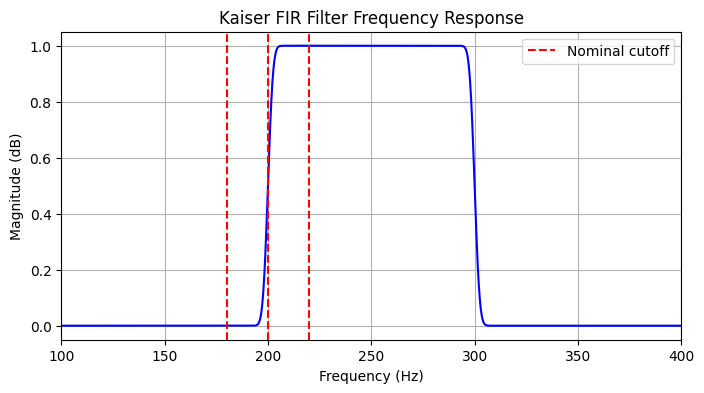

In [28]:


import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import kaiserord, firwin, freqz

# ----------------------------
# User parameters
# ----------------------------
fs = 1000          # Sampling frequency (Hz)
f_cut = 200        # Cutoff frequency (Hz) for lowpass
f_trans = 50       # Nominal transition width (Hz)
ripple_db = 200    # Desired stopband ripple (dB)

# ----------------------------
# Compute filter parameters
# ----------------------------
width_norm = f_trans / (fs / 2)          # Normalize transition width to Nyquist
numtaps, beta = kaiserord(ripple_db, width_norm)
if numtaps//2!=0:
    numtaps+=1

print(f"Designing Kaiser filter with {numtaps} taps and beta={beta:.2f}")

# ----------------------------
# Design the FIR filter
# ----------------------------
taps = firwin(numtaps, np.array([f_cut, f_cut+100]) / (fs / 2), window=('kaiser', beta), pass_zero=False)

# ----------------------------
# Frequency response
# ----------------------------
w, h = freqz(taps, worN=2048, fs=fs)

plt.figure(figsize=(8,4))
plt.plot(w, np.abs(h), 'b')
plt.title('Kaiser FIR Filter Frequency Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
# plt.ylim(-100, 5)
plt.axvline(f_cut, color='red', linestyle='--', label='Nominal cutoff')
plt.axvline(f_cut - f_trans/2, color='red', linestyle='--')
plt.axvline(f_cut + f_trans/2, color='red', linestyle='--')
plt.legend()
plt.show()






import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import kaiserord, firwin, freqz

# ----------------------------
# User parameters
# ----------------------------
fs = 1000          # Sampling frequency (Hz)
f_cut = 200        # Cutoff frequency (Hz) for lowpass
f_trans = 40       # Nominal transition width (Hz)
ripple_db = 1000     # Desired stopband ripple (dB)

# ----------------------------
# Compute filter parameters
# ----------------------------
width_norm = f_trans / (fs / 2)          # Normalize transition width to Nyquist
numtaps, beta = kaiserord(ripple_db, width_norm)
if numtaps//2!=0:
    numtaps+=1

print(f"Designing Kaiser filter with {numtaps} taps and beta={beta:.2f}")

# ----------------------------
# Design the FIR filter
# ----------------------------
taps = firwin(numtaps, np.array([f_cut, f_cut+100]) / (fs / 2), window=('kaiser', beta), pass_zero=False)

# ----------------------------
# Frequency response
# ----------------------------
w, h = freqz(taps, worN=2048, fs=fs)

plt.figure(figsize=(8,4))
plt.plot(w, np.abs(h), 'b')
plt.title('Kaiser FIR Filter Frequency Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
# plt.ylim(-100, 5)
plt.axvline(f_cut, color='red', linestyle='--', label='Nominal cutoff')
plt.axvline(f_cut - f_trans/2, color='red', linestyle='--')
plt.axvline(f_cut + f_trans/2, color='red', linestyle='--')
plt.xlim(100, 400)
plt.legend()
plt.show()






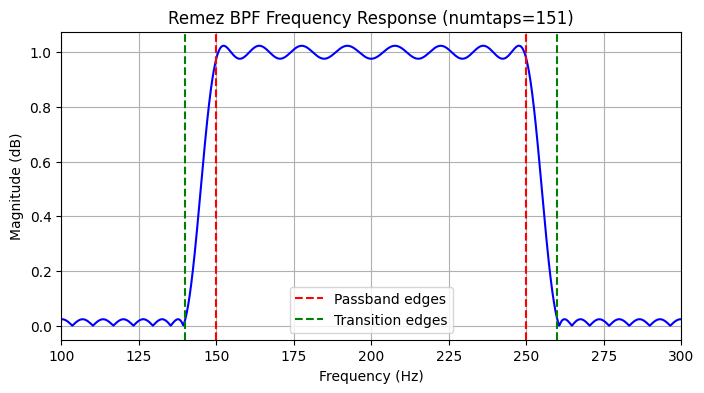

C:\Users\setht\AppData\Local\Temp\ipykernel_26784\79590711.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


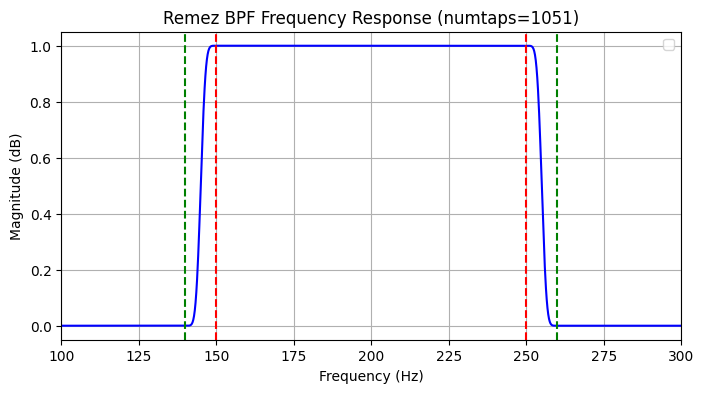

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import remez, freqz

# ----------------------------
# Sampling and filter specs
# ----------------------------
fs = 1000             # Sampling frequency (Hz)
center_freq = 200     # Center of bandpass (Hz)
bandwidth = 100       # Passband width (Hz)
trans_width = 10     # Transition width (Hz)

# Compute passband and stopband edges
pass_low = center_freq - bandwidth/2
pass_high = center_freq + bandwidth/2
stop_low = pass_low - trans_width
stop_high = pass_high + trans_width

# Frequency bands and desired gains
bands = [0, stop_low, pass_low, pass_high, stop_high, fs/2]
desired = [0, 1, 0]  # stop, pass, stop

# Two different filter lengths
numtaps_list = [151, 1051]  # smaller = gentler transition, larger = sharper

for numtaps in numtaps_list:
    # Design Remez bandpass FIR
    taps = remez(numtaps, bands, desired, fs=fs)
    
    # Frequency response
    w, h = freqz(taps, worN=4096, fs=fs)
    
    plt.figure(figsize=(8,4))
    plt.plot(w, np.abs(h), 'b')
    plt.title(f'Remez BPF Frequency Response (numtaps={numtaps})')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.grid(True)

    # Plot passband edges (red)
    plt.axvline(pass_low, color='red', linestyle='--', label='Passband edges' if numtaps==numtaps_list[0] else "")
    plt.axvline(pass_high, color='red', linestyle='--')
    
    # Plot transition edges (green)
    plt.axvline(stop_low, color='green', linestyle='--', label='Transition edges' if numtaps==numtaps_list[0] else "")
    plt.axvline(stop_high, color='green', linestyle='--')
    plt.xlim(100, 300)
    plt.legend()
    plt.show()